# Initialise

In [1]:
import pandas
import numpy as np
import matplotlib.pyplot as plt
import evaluate

from collections import Counter
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    pipeline,
)
from sklearn.metrics import confusion_matrix, roc_curve, auc, RocCurveDisplay


# Data Collection

## Data Candidates

https://huggingface.co/datasets/Enlightir/ai-vs-human-combined

+ (+) Most recently updated
+ (+) \> 500,000 entries
- (-) Author page/site is relatively blank or un-informative
- (-) No `readme` on data sources or verification of AI/human source

https://huggingface.co/datasets/Samambas/Human_vs_AI_Portuguese

+ (+) Foreign language, good to test with later
- (-) Same issues as above

https://huggingface.co/datasets/ahmadreza13/human-vs-Ai-generated-dataset

+ (+) Labels my model generated with
- (-) Similar data sourcing issues

https://huggingface.co/datasets/ilyasoulk/ai-vs-human-meta-llama-Llama-3.1-8B-Instruct-CNN / https://huggingface.co/datasets/zcamz/ai-vs-human-google-gemma-2-2b-it

+ (-) Datasets with specific models, good for later comparisons 
- (-) Relatively smaller

---

I think for now it's best to move forward with the `ahmadreza13/human-vs-Ai-generated-dataset` dataset - it's good that it labels by model, but it seems like mostly wikipedia. That might cause issues! But if those pop up in testing, come back here and change the tuning dataset!

In [2]:

dataset = load_dataset("ahmadreza13/human-vs-Ai-generated-dataset")

In [3]:
print("Models/sources:", set(dataset['train']['model'][:]))

Models/sources: {'claude', 'gemini-1.5-pro', 'wikipedia', 'Claude3-Opus', 'GPT4'}


## Data Exploration

In [4]:
print("Shape of training dataset:", dataset['train'].shape)


Shape of training dataset: (3614247, 3)


In [5]:
dataset['train'].column_names

['data', 'generated', 'model']

In [6]:
dataset = dataset.rename_column('generated', 'labels')
dataset = dataset["train"].train_test_split(test_size=0.1, seed=42)
dataset

DatasetDict({
    train: Dataset({
        features: ['data', 'labels', 'model'],
        num_rows: 3252822
    })
    test: Dataset({
        features: ['data', 'labels', 'model'],
        num_rows: 361425
    })
})

In [ ]:
import pandas
from collections import Counter

# plot a distribution of the number of counts of each source in the dataset

df = pandas.DataFrame.from_dict(Counter(dataset['train']['model'][:]), orient='index')
df.plot(kind='bar')


<Axes: >

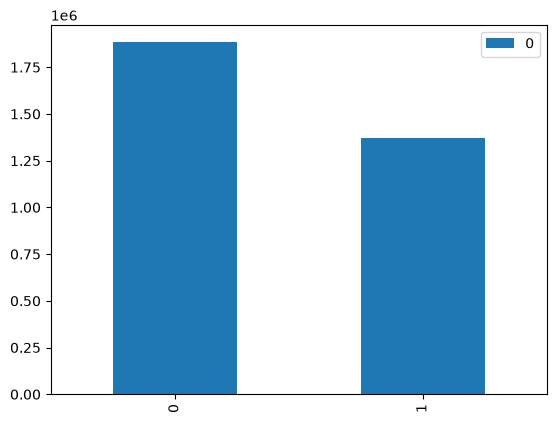

In [8]:
# now check total no. of generated vs human data

df = pandas.DataFrame.from_dict(Counter(dataset['train']['labels'][:]), orient='index')
df.plot(kind='bar')


In [9]:
# try checking, e.g., all wikipedia data is human. first, filter: 

temp = dataset['train']
temp = temp.filter(lambda example: example['model'] == 'wikipedia')

<Axes: >

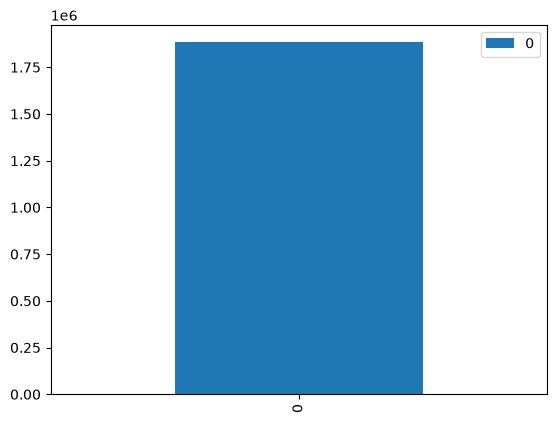

In [10]:
# then count and plot

temp = temp['labels'][:]
counts = Counter(temp)

df = pandas.DataFrame.from_dict(counts, orient='index')
df.plot(kind='bar')


In [11]:
# testing if counter works without slicing the dataset and loading all into mem
Counter(dataset['train']['model'])

Counter({'wikipedia': 1883392,
         'GPT4': 1335771,
         'claude': 28972,
         'Claude3-Opus': 3778,
         'gemini-1.5-pro': 909})

In [12]:
# try with pandas instead; faster!
dataset['train'].remove_columns('data').to_pandas().value_counts()

labels  model         
0       wikipedia         1883392
1       GPT4              1335771
        claude              28972
        Claude3-Opus         3778
        gemini-1.5-pro        909
Name: count, dtype: int64

In [13]:
# check features
dataset['train'].features

{'data': Value('string'), 'labels': Value('int64'), 'model': Value('string')}

In [14]:
# now just get a final no. of human vs ai to compare to
generated_counts = dataset['train'].remove_columns(['data', 'model']).to_pandas().value_counts()
generated_counts

labels
0         1883392
1         1369430
Name: count, dtype: int64

In [15]:
human_counts, ai_counts = generated_counts[0], generated_counts[1]
percentage_human = human_counts / (human_counts + ai_counts) * 100
print(f"Percentage of human data: {percentage_human:.2f}%")

Percentage of human data: 57.90%


# Tokenising

In [16]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased")

def preprocess_function(examples):
    tokenized = tokenizer(examples["data"], truncation=False)
    return {"token_length": [len(ids) for ids in tokenized["input_ids"]]}

tokenized_dataset = dataset.map(preprocess_function, batched=True)

In [17]:
lengths = tokenized_dataset['train'].remove_columns(['data', 'model', 'labels']).to_pandas()

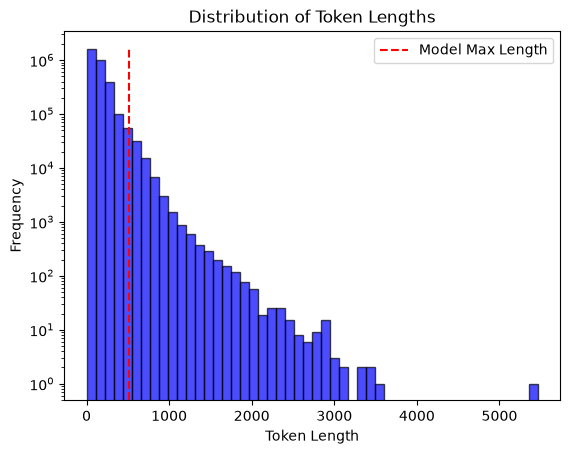

In [18]:
import matplotlib.pyplot as plt
plt.hist(lengths['token_length'], bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.vlines([tokenizer.model_max_length], ymin=0, ymax=plt.ylim()[1], colors='r', linestyles='dashed', label='Model Max Length')

plt.yscale('log')

plt.xlabel('Token Length')
plt.ylabel('Frequency')

plt.title('Distribution of Token Lengths')

plt.legend()
plt.show()

In [19]:
(lengths["token_length"] > tokenizer.model_max_length).mean()

np.float64(0.023285319639377747)

In [20]:
def token_length_analysis(tokenized_dataset, filter_model=None):
    if filter_model:
        tokenized_dataset = tokenized_dataset.filter(lambda x: x['model'] == filter_model)

    lengths = tokenized_dataset['train'].remove_columns(['data', 'model', 'labels']).to_pandas()
    
    plt.hist(lengths['token_length'], bins=50, alpha=0.7, color='blue', edgecolor='black')
    plt.vlines([tokenizer.model_max_length], ymin=0, ymax=plt.ylim()[1], colors='r', linestyles='dashed', label='Model Max Length')

    plt.yscale('log')

    plt.xlabel('Token Length')
    plt.ylabel('Frequency')

    plt.title('Distribution of Token Lengths')

    plt.legend()
    plt.show()

    print(f"Percentage of samples exceeding model max length: {(lengths['token_length'] > tokenizer.model_max_length).mean() * 100:.2f}%")  


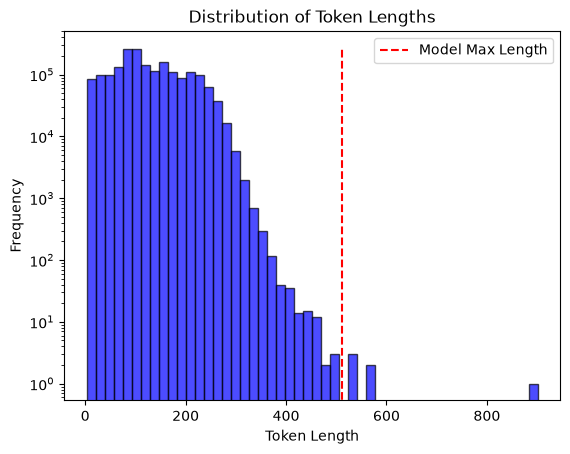

Percentage of samples exceeding model max length: 0.00%


In [21]:
token_length_analysis(tokenized_dataset, filter_model='wikipedia')

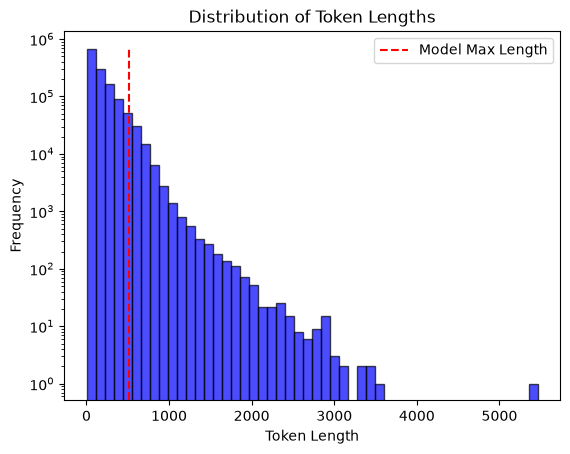

Percentage of samples exceeding model max length: 5.45%


In [22]:
token_length_analysis(tokenized_dataset, filter_model='GPT4')

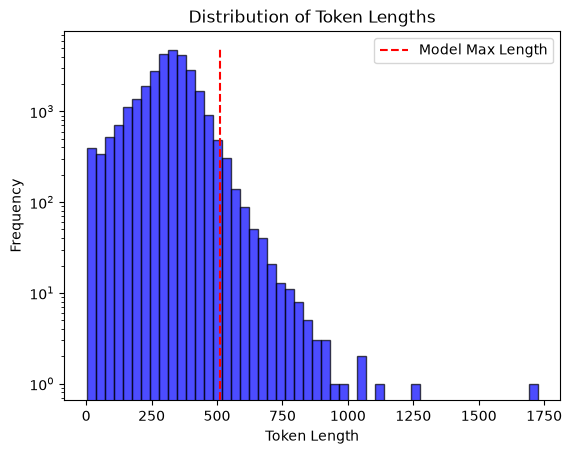

Percentage of samples exceeding model max length: 2.62%


In [23]:
token_length_analysis(tokenized_dataset, filter_model='claude')

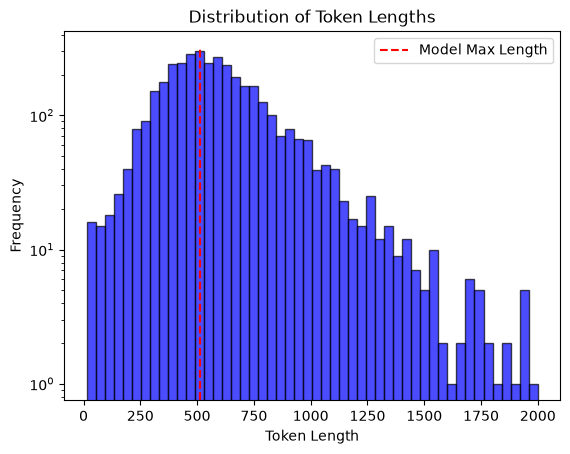

Percentage of samples exceeding model max length: 58.95%


In [24]:
token_length_analysis(tokenized_dataset, filter_model='Claude3-Opus')

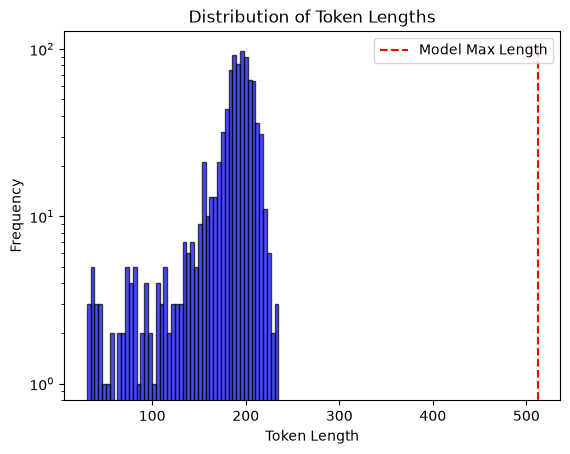

Percentage of samples exceeding model max length: 0.00%


In [25]:
token_length_analysis(tokenized_dataset, filter_model='gemini-1.5-pro')

## Notes

AI data skews longer. If having issues, maybe try cutting length earlier (eg 256). Then, the AI flag goes from 'super long text' to 'more likely to be at 256/semantically cut-off suddently' rather than just length itself. 

In [26]:
def preprocess_function(examples):
    return tokenizer(examples["data"], truncation=True)

tokenized_dataset = dataset.map(preprocess_function, batched=True)

from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Performance Metrics

In [27]:
import evaluate

accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

import numpy as np
from sklearn.metrics import confusion_matrix

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    tn, fp, fn, tp = confusion_matrix(labels, predictions).ravel()   

    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)

    accuracy_score = accuracy.compute(predictions=predictions, references=labels)["accuracy"] 
    f1_score = f1.compute(predictions=predictions, references=labels)["f1"]
    return {
        "accuracy": accuracy_score, 
        "f1": f1_score,
        "fpr" : fpr,
        "fnr" : fnr
        }


In [28]:
id2label = {0: "HUMAN", 1: "AI"}
label2id = {"HUMAN": 0, "AI": 1}

# Training

In [29]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert/distilbert-base-uncased", num_labels=2, id2label=id2label, label2id=label2id
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [40]:
training_args = TrainingArguments(
    output_dir="my_awesome_classifier",
    learning_rate=2e-5,
    per_device_train_batch_size=16, # can push higher w/ GPU vs mba's cpu
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    push_to_hub=False,
    fp16=True, # use GPU
)

trainer = Trainer(
    model=model,
    args=training_args,
    #train_dataset=tokenized_dataset["train"],
    train_dataset=tokenized_dataset["train"].shuffle(seed=42).select(range(50000)),
    #eval_dataset=tokenized_dataset["test"],
    eval_dataset=tokenized_dataset["test"].shuffle(seed=42).select(range(5000)),
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()
trainer.save_model("my_awesome_classifier")

Epoch,Training Loss,Validation Loss,Accuracy,F1,Fpr,Fnr
1,0.004965,0.005143,0.999000,0.998828,0.001046,0.000938


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

# Evaluating

In [41]:
from transformers import pipeline

text = "This is an example of text I have just written."
classifier = pipeline("sentiment-analysis", model="my_awesome_classifier")
classifier(text)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'AI', 'score': 0.9999910593032837}]

In [42]:
model_path = "my_awesome_classifier"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [ ]:
paired = load_dataset("ilyasoulk/ai-vs-human-meta-llama-Llama-3.1-8B-Instruct-CNN")["train"]  

def to_long(batch):
    texts = batch["ai"] + batch["human"]              # all AI, then all human
    labels = [1] * len(batch["ai"]) + [0] * len(batch["human"])
    return {"data": texts, "labels": labels}

# remove_columns drops the old 'ai'/'human' so only 'data' + 'labels' remain
long_ds = paired.map(to_long, batched=True, remove_columns=paired.column_names)

print(long_ds)                 
print(long_ds[0], long_ds[-1]) 


README.md:   0%|          | 0.00/1.14k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/15.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Dataset({
    features: ['data', 'labels'],
    num_rows: 10000
})
{'data': 'bond. The court documents also alleged that Mark Leonard had a history of embezzlement and had been involved in other scams, including a 2008 incident where he was accused of stealing from his former employer to pay off debt.\n\nProsecutor Terry Curry told the court that the evidence against the trio is "overwhelming" and that they were motivated by financial gain. "The state will present evidence that Monserrate Shirley, Mark Leonard, and Bob Leonard deliberately set fire to the home of Jennifer and John Longworth in order to collect on an insurance policy," Curry said.\n\nThe explosion occurred on November 10, 2012, at around 11:15 pm, when a gas leak caused a massive blast that destroyed 33 homes in Richmond Hill. The couple\'s home was one of the most severely damaged, with neighbors describing the scene as "apocalyptic."\n\nMonserrate Shirley, who appeared in court with tears streaming down her face, plea

In [ ]:
eval_args = TrainingArguments(
    output_dir="eval_tmp", 
    per_device_eval_batch_size=16, 
    fp16=True, 
    report_to="none",
)

evaluator = Trainer(
    model=model,
    args=eval_args,
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,   # defined in your earlier cell
)


In [45]:
tokenized_new = long_ds.map(preprocess_function, batched=True)
metrics = evaluator.evaluate(eval_dataset=tokenized_new)
metrics


Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Training Loss,Validation Loss,Step,Accuracy,F1,Fpr,Fnr
No log,5.647583,0,0.500400,0.666844,0.999200,0.000000


{'eval_loss': 5.647583484649658,
 'eval_accuracy': 0.5004,
 'eval_f1': 0.6668444918644972,
 'eval_fpr': 0.9992,
 'eval_fnr': 0.0}

These results are awful! It's self-evident that the model is just catching some flag that's showing it what is Wikipedia vs. AI. So, let's try with better training data. While looking again I found a good candidate in: `acmc/multi_domain_ai_human_text`. It's sourced, has a dataset card, and a general readme. It looks much more reliable!

# New Training Dataset

In [2]:
new_dataset = load_dataset('acmc/multi_domain_ai_human_text')

<Axes: title={'center': 'Distribution of Generator Models in New Dataset'}>

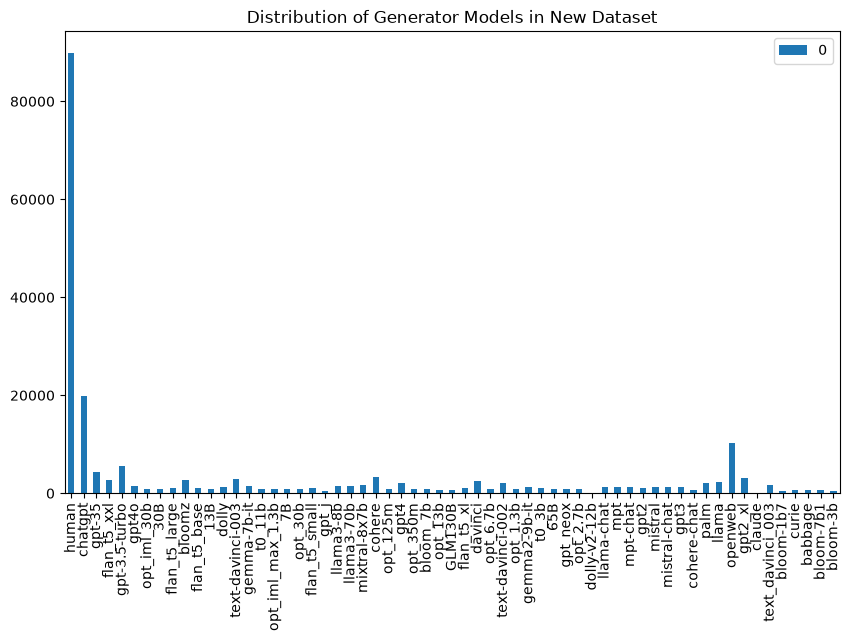

In [3]:
df = pandas.DataFrame.from_dict(Counter(new_dataset['train']['generator_model'][:]), orient='index')
df.plot(kind='bar', figsize=(10, 6), title='Distribution of Generator Models in New Dataset')

<Axes: title={'center': 'Distribution of Labels in New Dataset'}>

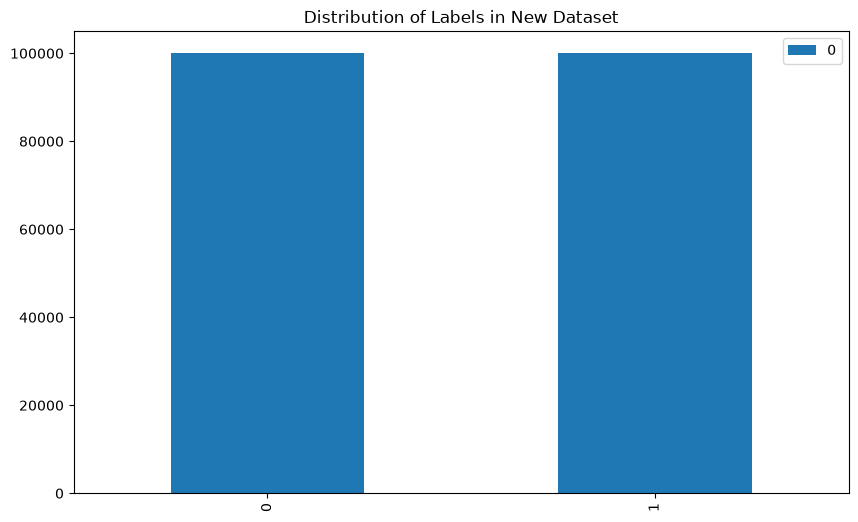

In [4]:
df = pandas.DataFrame.from_dict(Counter(new_dataset['train']['label'][:]), orient='index')
df.plot(kind='bar', figsize=(10, 6), title='Distribution of Labels in New Dataset')

## Exploration

In [5]:
tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased")

def preprocess_function(examples):
    tokenized = tokenizer(examples["text"], truncation=False)
    return {"token_length": [len(ids) for ids in tokenized["input_ids"]]}

tokenized_dataset = new_dataset.map(preprocess_function, batched=True)

In [6]:
def token_length_analysis(tokenized_dataset, filter_model=None, filter_label=None, log=False):
    if filter_model is not None:
        tokenized_dataset = tokenized_dataset.filter(lambda x: x['generator_model'] == filter_model)
    if filter_label is not None:
        tokenized_dataset = tokenized_dataset.filter(lambda x: x['label'] == filter_label)

    lengths = tokenized_dataset['train'].select_columns(['token_length']).to_pandas()

    plt.hist(lengths['token_length'], bins=50, alpha=0.7, color='blue', edgecolor='black')
    plt.vlines([tokenizer.model_max_length], ymin=0, ymax=plt.ylim()[1], colors='r', linestyles='dashed', label='Model Max Length')

    if log:
        plt.yscale('log')

    plt.xlabel('Token Length')
    plt.ylabel('Frequency')

    plt.title('Distribution of Token Lengths')

    plt.legend()
    plt.show()

    print(f"Percentage of samples exceeding model max length: {(lengths['token_length'] > tokenizer.model_max_length).mean() * 100:.2f}%")  


### Token Length by Model

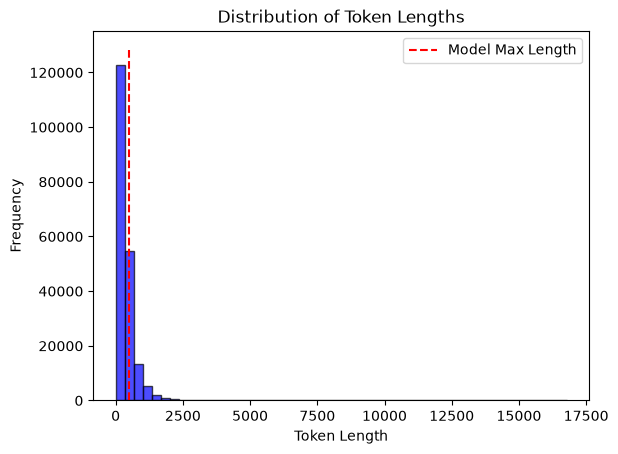

Percentage of samples exceeding model max length: 18.43%


In [7]:
token_length_analysis(tokenized_dataset)

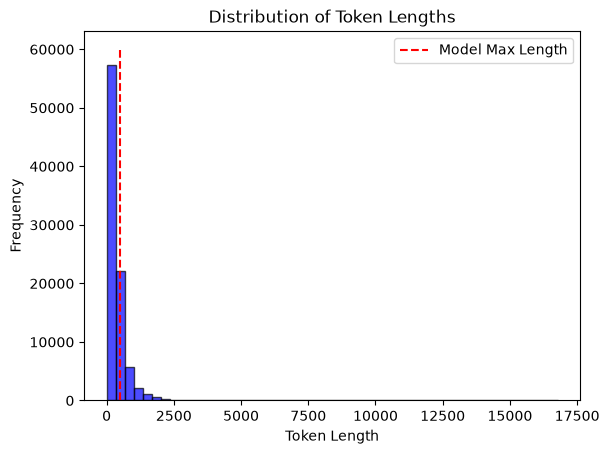

Percentage of samples exceeding model max length: 18.86%


In [8]:
token_length_analysis(tokenized_dataset, filter_model='human')

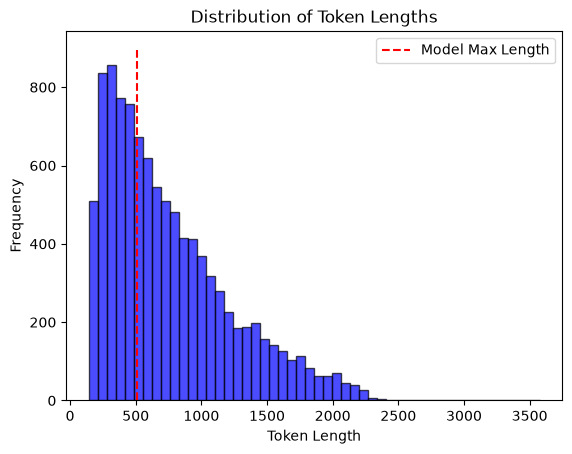

Percentage of samples exceeding model max length: 60.77%


In [9]:
token_length_analysis(tokenized_dataset, filter_model='openweb')

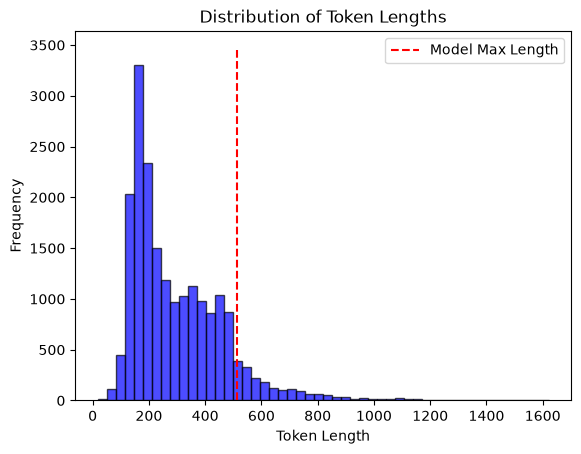

Percentage of samples exceeding model max length: 8.96%


In [10]:
token_length_analysis(tokenized_dataset, filter_model='chatgpt')

### Token Length by Label (Human/AI)

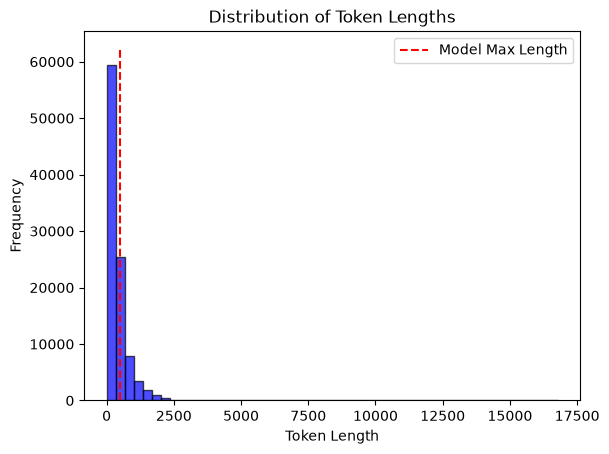

Percentage of samples exceeding model max length: 23.13%


In [11]:
token_length_analysis(tokenized_dataset, filter_label=0)

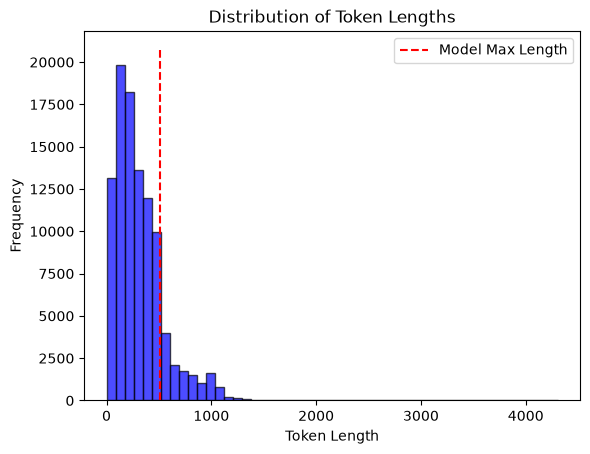

Percentage of samples exceeding model max length: 13.74%


In [12]:
token_length_analysis(tokenized_dataset, filter_label=1)

Looks worse when looking at individual models, but the difference is perhaps not the worst. Worth flagging and coming back to!

## Tokenising

In [13]:
def preprocess_function(examples):
    return tokenizer(examples["text"], truncation=True)

tokenized_dataset = new_dataset.map(preprocess_function, batched=True)

from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

## Metrics

In [14]:
import evaluate

accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

import numpy as np
from sklearn.metrics import confusion_matrix

def quick_softmax(logits):
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def compute_metrics(eval_pred, threshold=None):
    predictions, labels = eval_pred
    if threshold is not None:
        probs = quick_softmax(predictions)[:, 1]
        predictions = (probs > threshold).astype(int)
    else:
        predictions = np.argmax(predictions, axis=1)

    tn, fp, fn, tp = confusion_matrix(labels, predictions).ravel()   

    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)

    accuracy_score = accuracy.compute(predictions=predictions, references=labels)["accuracy"] 
    f1_score = f1.compute(predictions=predictions, references=labels)["f1"]
    return {
        "accuracy": accuracy_score, 
        "f1": f1_score,
        "fpr" : fpr,
        "fnr" : fnr
        }


In [15]:
id2label = {0: "HUMAN", 1: "AI"}
label2id = {"HUMAN": 0, "AI": 1}

## Training

In [16]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert/distilbert-base-uncased", num_labels=2, id2label=id2label, label2id=label2id
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [17]:
training_args = TrainingArguments(
    output_dir="margnap_classifier",
    learning_rate=2e-5,
    per_device_train_batch_size=16, # can push higher w/ GPU vs mba's cpu
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    push_to_hub=False,
    fp16=True, # use GPU
)

trainer = Trainer(
    model=model,
    args=training_args,
    #train_dataset=tokenized_dataset["train"],
    train_dataset=tokenized_dataset["train"].shuffle(seed=42).select(range(50000)),
    #eval_dataset=tokenized_dataset["test"],
    eval_dataset=tokenized_dataset["test"].shuffle(seed=42).select(range(5000)),
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()
trainer.save_model("margnap_classifier")

Epoch,Training Loss,Validation Loss,Accuracy,F1,Fpr,Fnr
1,0.279137,0.397370,0.850000,0.861008,0.229200,0.070800


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

<!-- ## Evaluating -->

In [18]:
model_path = "margnap_classifier"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [19]:
paired = load_dataset("ilyasoulk/ai-vs-human-meta-llama-Llama-3.1-8B-Instruct-CNN")["train"] 

def to_long(batch):
    texts = batch["ai"] + batch["human"]              # all AI, then all human
    labels = [1] * len(batch["ai"]) + [0] * len(batch["human"])
    return {"text": texts, "labels": labels}

# remove_columns drops the old 'ai'/'human' so only 'text' + 'labels' remain
long_ds = paired.map(to_long, batched=True, remove_columns=paired.column_names)

print(long_ds)                 # should show ~10000 rows, columns: ['text', 'labels']
print(long_ds[0], long_ds[-1]) # eyeball one AI and one human example


Dataset({
    features: ['text', 'labels'],
    num_rows: 10000
})
{'text': 'bond. The court documents also alleged that Mark Leonard had a history of embezzlement and had been involved in other scams, including a 2008 incident where he was accused of stealing from his former employer to pay off debt.\n\nProsecutor Terry Curry told the court that the evidence against the trio is "overwhelming" and that they were motivated by financial gain. "The state will present evidence that Monserrate Shirley, Mark Leonard, and Bob Leonard deliberately set fire to the home of Jennifer and John Longworth in order to collect on an insurance policy," Curry said.\n\nThe explosion occurred on November 10, 2012, at around 11:15 pm, when a gas leak caused a massive blast that destroyed 33 homes in Richmond Hill. The couple\'s home was one of the most severely damaged, with neighbors describing the scene as "apocalyptic."\n\nMonserrate Shirley, who appeared in court with tears streaming down her face, plea

In [20]:
eval_args = TrainingArguments(
    output_dir="eval_tmp", 
    per_device_eval_batch_size=16, 
    fp16=True, 
    report_to="none",
)

evaluator = Trainer(
    model=model,
    args=eval_args,
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,   # defined in your earlier cell
)

tokenized_new = long_ds.map(preprocess_function, batched=True)
metrics = evaluator.evaluate(eval_dataset=tokenized_new)
metrics


Training Loss,Validation Loss,Step,Accuracy,F1,Fpr,Fnr
No log,0.274329,0,0.896000,0.905677,0.206600,0.001400


{'eval_loss': 0.2743288576602936,
 'eval_accuracy': 0.896,
 'eval_f1': 0.9056774895701071,
 'eval_fpr': 0.2066,
 'eval_fnr': 0.0014}

Promising metrics! The FPR on the original validation set was quite high though. I'm just going to try a longer test training set and see how that affects things.

### Extending Training Data

In [21]:
id2label = {0: "HUMAN", 1: "AI"}
label2id = {"HUMAN": 0, "AI": 1}

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert/distilbert-base-uncased", num_labels=2, id2label=id2label, label2id=label2id
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [22]:
training_args = TrainingArguments(
    output_dir="margnap_classifier_full",
    learning_rate=2e-5,
    per_device_train_batch_size=16, # can push higher w/ GPU vs mba's cpu
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    push_to_hub=False,
    fp16=True, # use GPU
)

trainer = Trainer(
    model=model,
    args=training_args,
    #train_dataset=tokenized_dataset["train"],
    train_dataset=tokenized_dataset["train"].shuffle(seed=42),
    #eval_dataset=tokenized_dataset["test"],
    eval_dataset=tokenized_dataset["validation"].shuffle(seed=42),
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()
trainer.save_model("margnap_classifier_full")

Epoch,Training Loss,Validation Loss,Accuracy,F1,Fpr,Fnr
1,0.182564,0.329852,0.887000,0.894254,0.181600,0.044400


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [23]:
import functools


model_path = "margnap_classifier_full"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


eval_args = TrainingArguments(
    output_dir="eval_tmp", 
    per_device_eval_batch_size=16, 
    fp16=True, 
    report_to="none",
)

evaluator = Trainer(
    model=model,
    args=eval_args,
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=functools.partial(compute_metrics, threshold=None),   
)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [24]:
np.exp(evaluator.predict(tokenized_dataset['validation']).predictions[:])

array([[1.4043088e-02, 7.4918907e+01],
       [4.0806241e+00, 2.4989393e-01],
       [1.3988339e-02, 7.3757393e+01],
       ...,
       [2.8702207e-02, 3.9095825e+01],
       [1.3708483e+00, 7.7804059e-01],
       [1.3599773e-01, 8.4715948e+00]], shape=(5000, 2), dtype=float32)

In [25]:
np.exp(evaluator.predict(tokenized_dataset['validation']).predictions[:]).sum(axis=1, keepdims=True)

array([[74.93295  ],
       [ 4.3305182],
       [73.77138  ],
       ...,
       [39.124527 ],
       [ 2.1488888],
       [ 8.607593 ]], shape=(5000, 1), dtype=float32)

In [26]:
def quick_softmax(logits):
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

# Pre Threshold Tuning Evaluations

In [27]:
print("Evaluating on Validation Dataset:")
metrics = evaluator.evaluate(eval_dataset=tokenized_dataset["validation"])
print(metrics)
print("\n", "-"*50, "\n")

print("Evaluating on CNN Llama Dataset:")
metrics = evaluator.evaluate(eval_dataset=tokenized_new)
print(metrics)
print("\n", "-"*50, "\n")

print("Evaluating on Test Dataset:")
metrics = evaluator.evaluate(eval_dataset=tokenized_dataset["test"])
print(metrics)
print("\n", "-"*50, "\n")

print("Evaluating on Test Adversarial Characters Dataset:")
metrics = evaluator.evaluate(eval_dataset=tokenized_dataset["test_adversarial_char"])
print(metrics)
print("\n", "-"*50, "\n")

print("Evaluating on Test Adversarial Paraphrase Dataset:")
metrics = evaluator.evaluate(eval_dataset=tokenized_dataset["test_adversarial_paraphrase"])
print(metrics)
print("\n", "-"*50, "\n")

print("Evaluating on Test Adversarial Words Dataset:")
metrics = evaluator.evaluate(eval_dataset=tokenized_dataset["test_adversarial_word"])
print(metrics)
print("\n", "-"*50, "\n")

print("Evaluating on Test OOD Domain Dataset:")
metrics = evaluator.evaluate(eval_dataset=tokenized_dataset["test_ood_domain"])
print(metrics)
print("\n", "-"*50, "\n")

print("Evaluating on Test OOD Language Dataset:")
metrics = evaluator.evaluate(eval_dataset=tokenized_dataset["test_ood_language"])
print(metrics)
print("\n", "-"*50, "\n")

print("Evaluating on Test OOD Model Dataset:")
metrics = evaluator.evaluate(eval_dataset=tokenized_dataset["test_ood_model"])
print(metrics)
print("\n", "-"*50, "\n")


Evaluating on Validation Dataset:


Training Loss,Validation Loss,Step,Accuracy,F1,Fpr,Fnr
No log,0.329850,0,0.887000,0.894254,0.181600,0.044400


{'eval_loss': 0.329849511384964, 'eval_accuracy': 0.887, 'eval_f1': 0.894254164327157, 'eval_fpr': 0.1816, 'eval_fnr': 0.0444}

 -------------------------------------------------- 

Evaluating on CNN Llama Dataset:


Training Loss,Validation Loss,Step,Accuracy,F1,Fpr,Fnr
No log,0.318026,0,0.894400,0.904417,0.210400,0.000800


{'eval_loss': 0.31802576780319214, 'eval_accuracy': 0.8944, 'eval_f1': 0.9044170890658942, 'eval_fpr': 0.2104, 'eval_fnr': 0.0008}

 -------------------------------------------------- 

Evaluating on Test Dataset:


...

{'eval_loss': 0.8578664064407349, 'eval_accuracy': 0.6696, 'eval_f1': 0.6971030436376972, 'eval_fpr': 0.4212, 'eval_fnr': 0.2396}

 -------------------------------------------------- 

Evaluating on Test OOD Language Dataset:


Training Loss,Validation Loss,Step,Accuracy,F1,Fpr,Fnr
No log,0.593863,0,0.681600,0.623284,0.163600,0.473200


{'eval_loss': 0.593862771987915, 'eval_accuracy': 0.6816, 'eval_f1': 0.6232844297207761, 'eval_fpr': 0.1636, 'eval_fnr': 0.4732}

 -------------------------------------------------- 

Evaluating on Test OOD Model Dataset:


Training Loss,Validation Loss,Step,Accuracy,F1,Fpr,Fnr
No log,0.688168,0,0.788000,0.804139,0.294400,0.129600


{'eval_loss': 0.6881682276725769, 'eval_accuracy': 0.788, 'eval_f1': 0.804138950480414, 'eval_fpr': 0.2944, 'eval_fnr': 0.1296}

 -------------------------------------------------- 



# Threshold Tuning

In [28]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# y_true = tokenized_dataset['validation'].select_columns(['label']).to_pandas()['label']  # true labels
# y_scores = evaluator.predict(tokenized_dataset['validation']).predictions[:, 1]  # predicted probabilities

# use softmax to get probabilities for the positive class (AI)
y_true = tokenized_dataset['validation'].select_columns(['label']).to_pandas()['label']  # true labels
y_scores = quick_softmax(evaluator.predict(tokenized_dataset['validation']).predictions)[:, 1]  # predicted probabilities for AI class

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

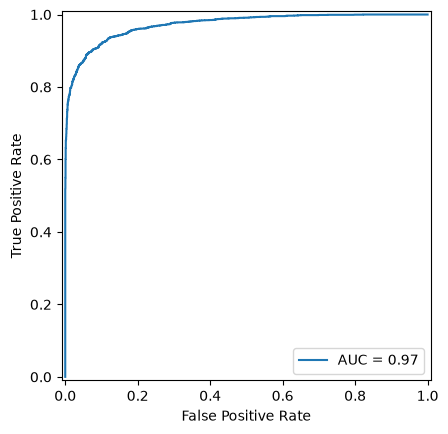

In [29]:
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot()

In [30]:
index = len(fpr[fpr < 0.01])
print("Max FPR below 0.01 occurs at index:", index)
print("FPR at index:", fpr[index])
print("TPR at index:", tpr[index])
print("Threshold at index:", thresholds[index])

Max FPR below 0.01 occurs at index: 619
FPR at index: 0.01
TPR at index: 0.7728
Threshold at index: 0.9960622191429138


In [31]:
# set threshold

threshold = thresholds[index]

eval_args = TrainingArguments(
    output_dir="eval_tmp", 
    per_device_eval_batch_size=16, 
    fp16=True, 
    report_to="none",
)

evaluator = Trainer(
    model=model,
    args=eval_args,
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=functools.partial(compute_metrics, threshold=threshold),   
)

In [32]:
print("Evaluating on Validation Dataset:")
metrics = evaluator.evaluate(eval_dataset=tokenized_dataset["validation"])
print(metrics)
print("\n", "-"*50, "\n")

print("Evaluating on CNN Llama Dataset:")
metrics = evaluator.evaluate(eval_dataset=tokenized_new)
print(metrics)
print("\n", "-"*50, "\n")

print("Evaluating on Test Dataset:")
metrics = evaluator.evaluate(eval_dataset=tokenized_dataset["test"])
print(metrics)
print("\n", "-"*50, "\n")

print("Evaluating on Test Adversarial Characters Dataset:")
metrics = evaluator.evaluate(eval_dataset=tokenized_dataset["test_adversarial_char"])
print(metrics)
print("\n", "-"*50, "\n")

print("Evaluating on Test Adversarial Paraphrase Dataset:")
metrics = evaluator.evaluate(eval_dataset=tokenized_dataset["test_adversarial_paraphrase"])
print(metrics)
print("\n", "-"*50, "\n")

print("Evaluating on Test Adversarial Words Dataset:")
metrics = evaluator.evaluate(eval_dataset=tokenized_dataset["test_adversarial_word"])
print(metrics)
print("\n", "-"*50, "\n")

print("Evaluating on Test OOD Domain Dataset:")
metrics = evaluator.evaluate(eval_dataset=tokenized_dataset["test_ood_domain"])
print(metrics)
print("\n", "-"*50, "\n")

print("Evaluating on Test OOD Language Dataset:")
metrics = evaluator.evaluate(eval_dataset=tokenized_dataset["test_ood_language"])
print(metrics)
print("\n", "-"*50, "\n")

print("Evaluating on Test OOD Model Dataset:")
metrics = evaluator.evaluate(eval_dataset=tokenized_dataset["test_ood_model"])
print(metrics)
print("\n", "-"*50, "\n")


Evaluating on Validation Dataset:


Training Loss,Validation Loss,Step,Accuracy,F1,Fpr,Fnr
No log,0.329850,0,0.881600,0.867145,0.009600,0.227200


{'eval_loss': 0.329849511384964, 'eval_accuracy': 0.8816, 'eval_f1': 0.8671454219030521, 'eval_fpr': 0.0096, 'eval_fnr': 0.2272}

 -------------------------------------------------- 

Evaluating on CNN Llama Dataset:


Training Loss,Validation Loss,Step,Accuracy,F1,Fpr,Fnr
No log,0.318026,0,0.990500,0.990514,0.011000,0.008000


{'eval_loss': 0.31802576780319214, 'eval_accuracy': 0.9905, 'eval_f1': 0.9905142286570144, 'eval_fpr': 0.011, 'eval_fnr': 0.008}

 -------------------------------------------------- 

Evaluating on Test Dataset:


...

{'eval_loss': 0.8578664064407349, 'eval_accuracy': 0.6292, 'eval_f1': 0.42314872433105166, 'eval_fpr': 0.0136, 'eval_fnr': 0.728}

 -------------------------------------------------- 

Evaluating on Test OOD Language Dataset:


Training Loss,Validation Loss,Step,Accuracy,F1,Fpr,Fnr
No log,0.593863,0,0.591000,0.307953,0.000000,0.818000


{'eval_loss': 0.593862771987915, 'eval_accuracy': 0.591, 'eval_f1': 0.3079526226734349, 'eval_fpr': 0.0, 'eval_fnr': 0.818}

 -------------------------------------------------- 

Evaluating on Test OOD Model Dataset:


Training Loss,Validation Loss,Step,Accuracy,F1,Fpr,Fnr
No log,0.688168,0,0.813800,0.778597,0.027200,0.345200


{'eval_loss': 0.6881682276725769, 'eval_accuracy': 0.8138, 'eval_f1': 0.7785969084423305, 'eval_fpr': 0.0272, 'eval_fnr': 0.3452}

 -------------------------------------------------- 



In [48]:
raw_logits_ood_domain = trainer.predict(tokenized_dataset['test_ood_domain'])
raw_logits_cnn_llama = trainer.predict(tokenized_new)


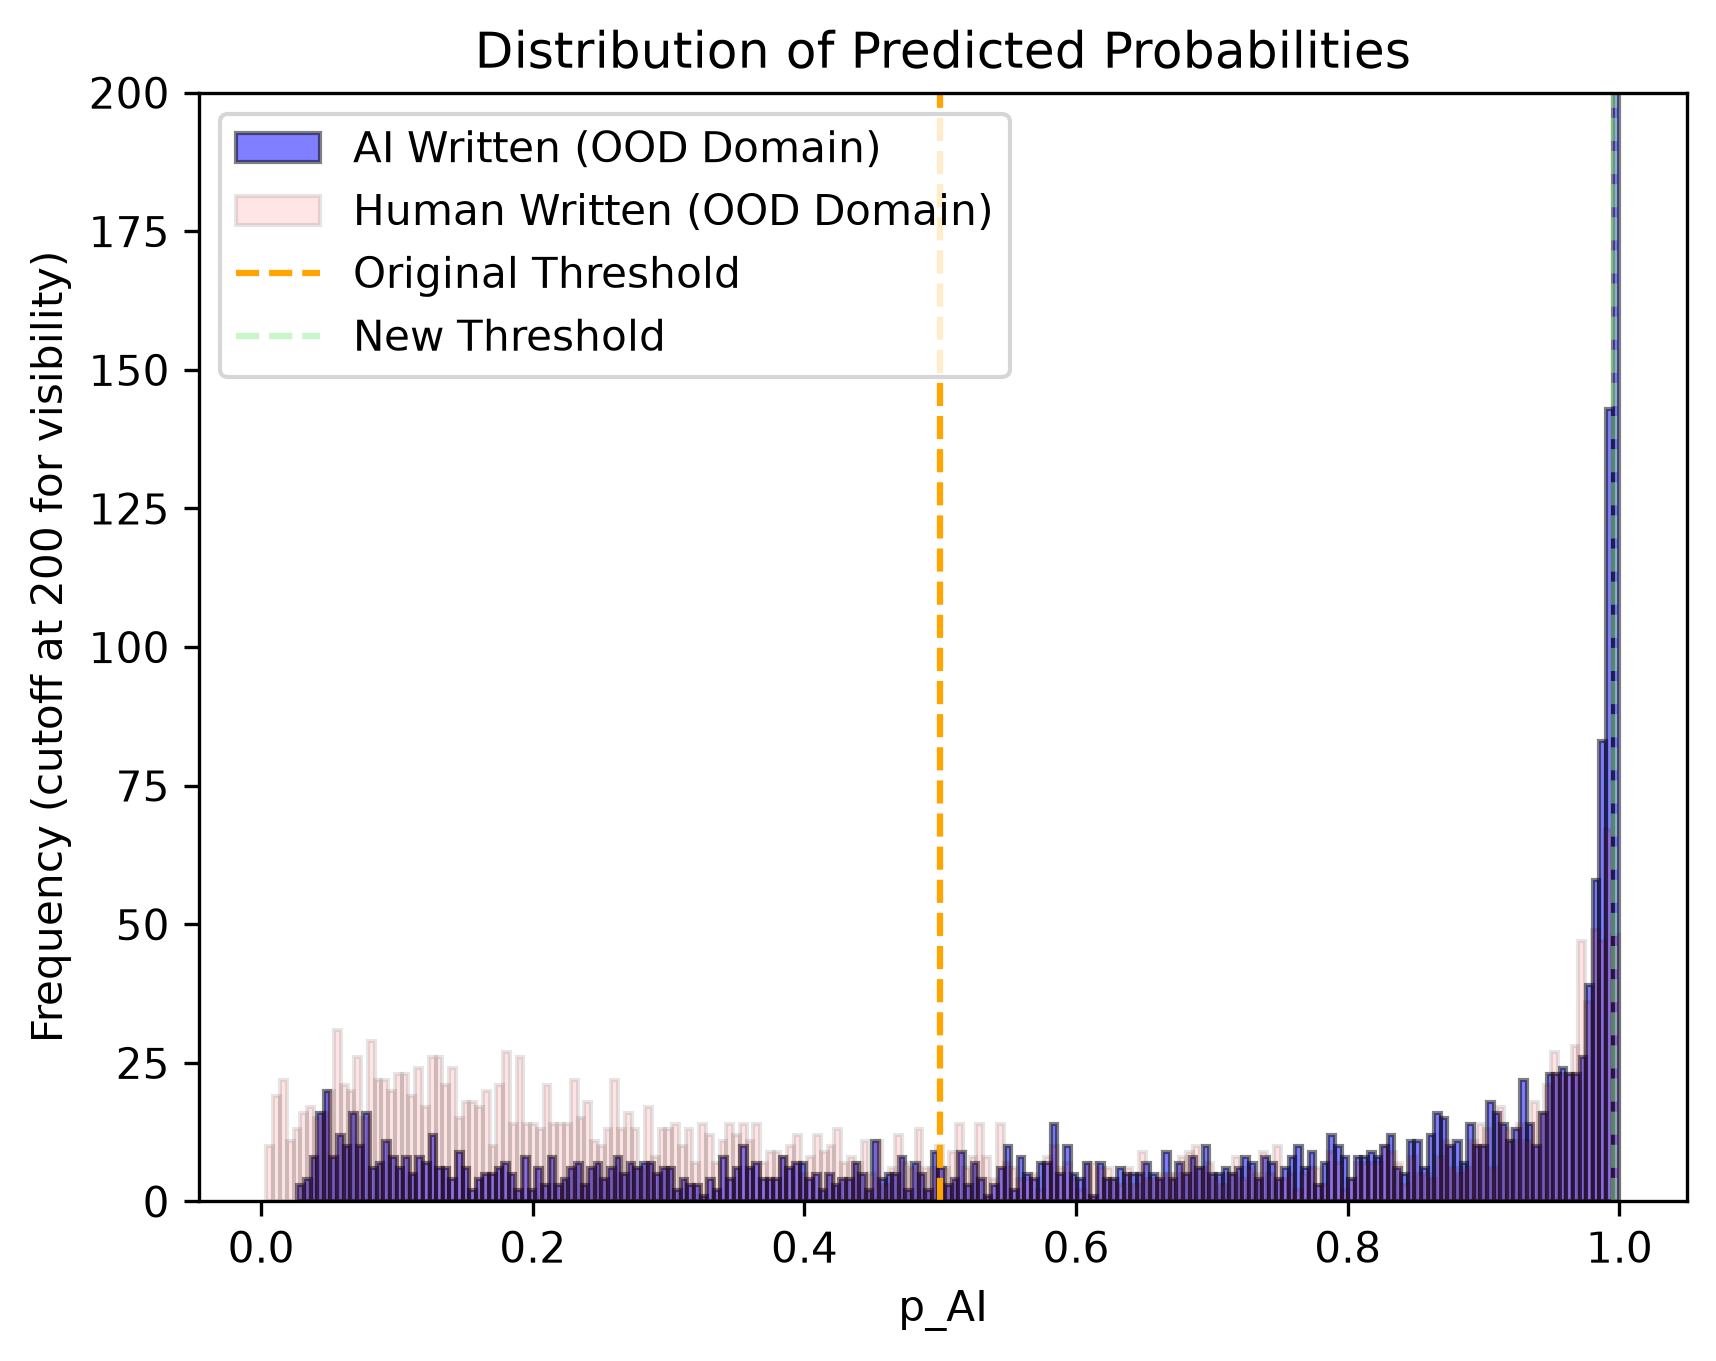

In [78]:

probabilities_ood_domain = quick_softmax(raw_logits_ood_domain.predictions)
# boolean mask label id's for where we have actual AI 
mask = raw_logits_ood_domain.label_ids == 1
p_ai_ood_domain = probabilities_ood_domain[:, [1]]
p_ai_ood_domain_true = p_ai_ood_domain[mask]
p_ai_ood_domain_false = p_ai_ood_domain[~mask]

probabilities_cnn_llama = quick_softmax(raw_logits_cnn_llama.predictions)
# boolean mask label id's for where we have actual AI 
mask = raw_logits_cnn_llama.label_ids == 1
p_ai_cnn_llama = probabilities_cnn_llama[:, [1]]
p_ai_cnn_llama_true = p_ai_cnn_llama[mask]
p_ai_cnn_llama_false = p_ai_cnn_llama[~mask]

plt.hist(p_ai_ood_domain_true, bins=200, alpha=0.5, label='AI Written (OOD Domain)', color='blue', edgecolor='black')
plt.hist(p_ai_ood_domain_false, bins=200, alpha=0.1, label='Human Written (OOD Domain)', color='red', edgecolor='black')

plt.vlines(0.5, ymin=0, ymax=plt.ylim()[1], colors='orange', linestyles='dashed', label='Original Threshold')
plt.vlines([threshold], ymin=0, ymax=plt.ylim()[1], colors='lightgreen', alpha=0.5, linestyles='dashed', label='New Threshold')

plt.ylim(0,200)
plt.xlabel('p_AI')
plt.ylabel('Frequency (cutoff at 200 for visibility)')
plt.title('Distribution of Predicted Probabilities')
plt.legend()
plt.gcf().set_dpi(300)

plt.show()

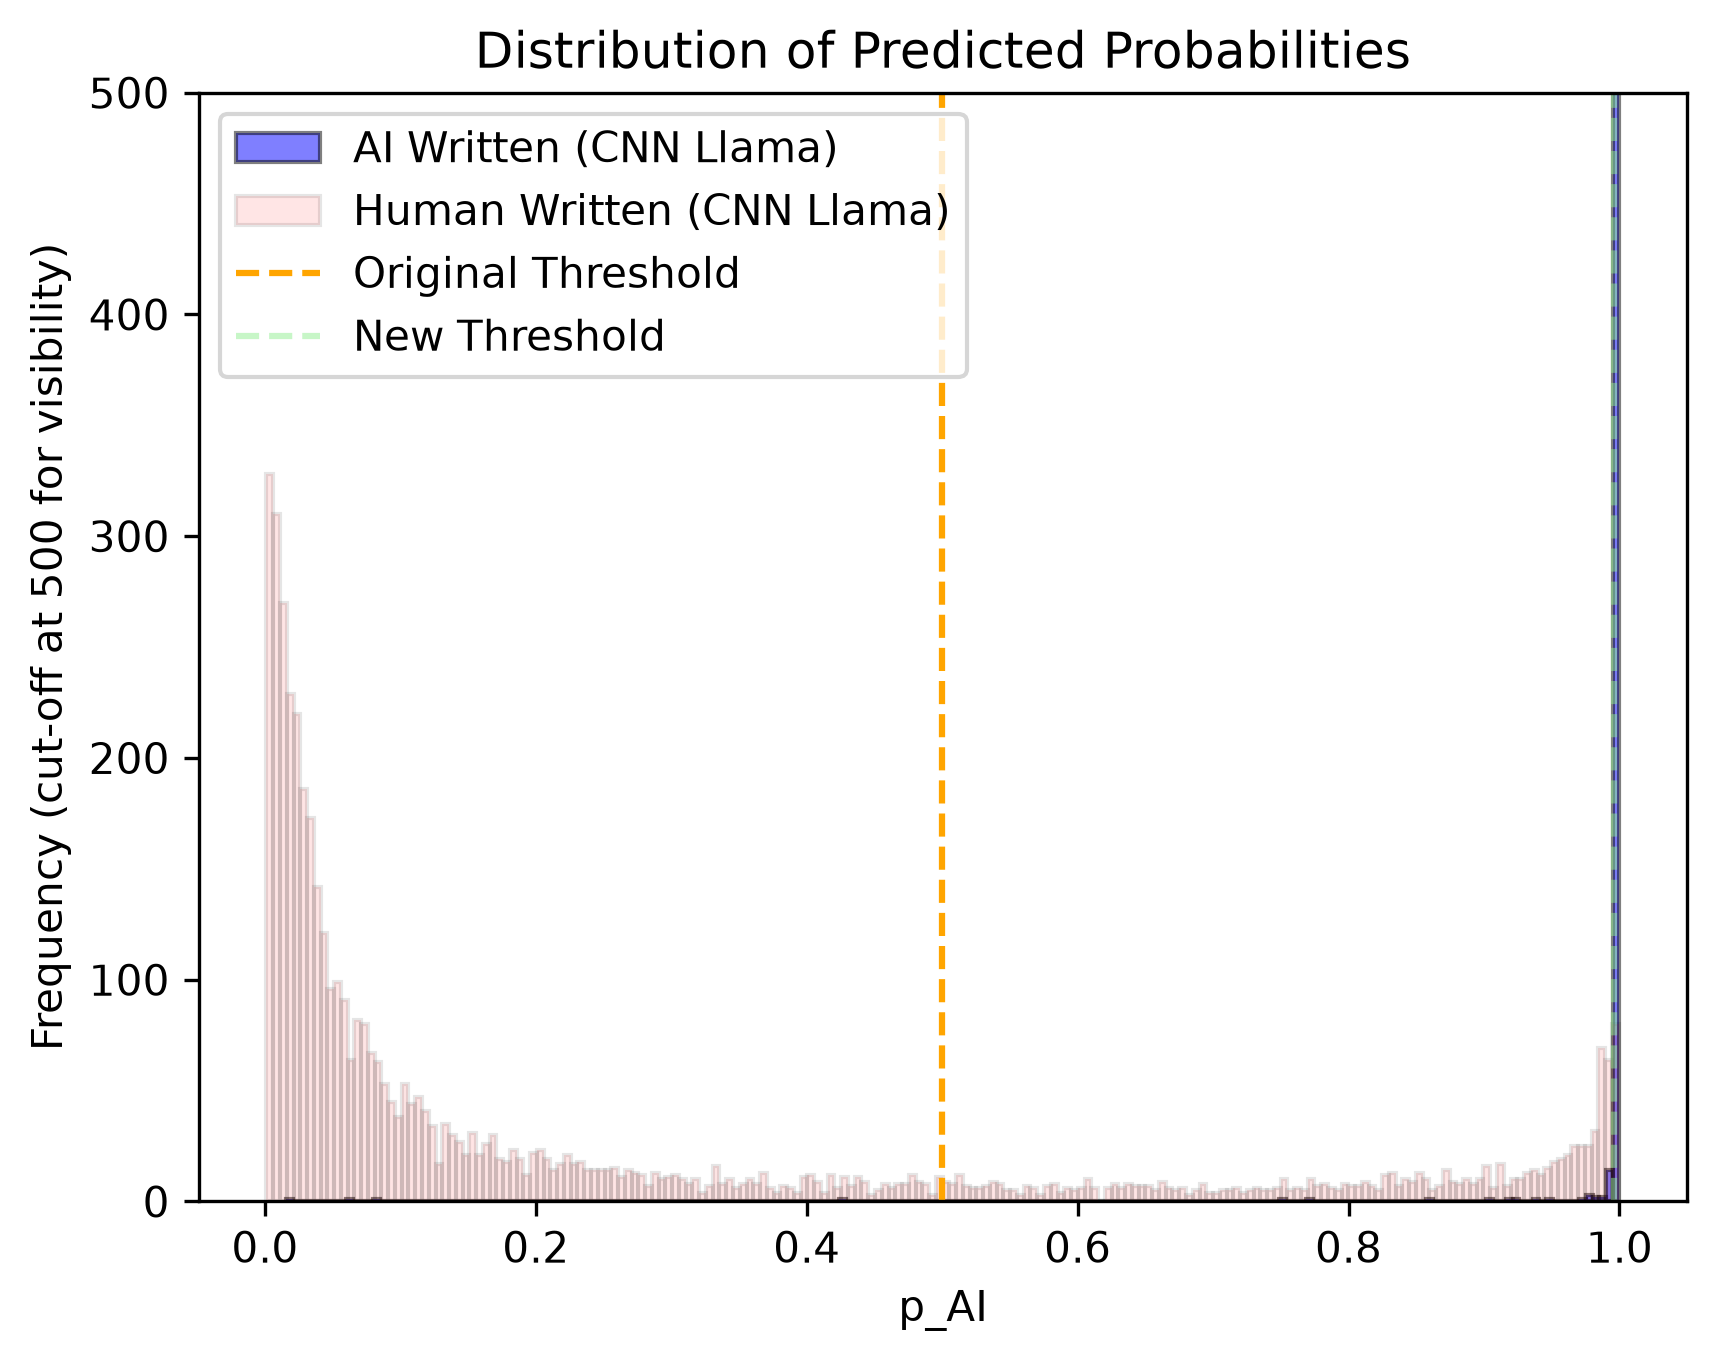

In [79]:
plt.hist(p_ai_cnn_llama_true, bins=200, alpha=0.5, label='AI Written (CNN Llama)', color='blue', edgecolor='black')
plt.hist(p_ai_cnn_llama_false, bins=200, alpha=0.1, label='Human Written (CNN Llama)', color='red', edgecolor='black')

plt.vlines(0.5, ymin=0, ymax=plt.ylim()[1], colors='orange', linestyles='dashed', label='Original Threshold')
plt.vlines([threshold], ymin=0, ymax=plt.ylim()[1], colors='lightgreen', alpha=0.5, linestyles='dashed', label='New Threshold')

plt.xlabel('p_AI')
plt.ylabel('Frequency (cut-off at 500 for visibility)')
plt.ylim(0, 500)  # Set the y-axis limit to a maximum of 1000
plt.title('Distribution of Predicted Probabilities')
plt.legend()
plt.gcf().set_dpi(300)
plt.show()